<a href="https://colab.research.google.com/github/mahigarg0403-blip/Customer-purchase-prediction_mahi_bhumika/blob/main/notebooks/step5_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
path = '/content/drive/MyDrive/CPP-ML PROJECT-BHUMIKA-MAHI/'
print(os.listdir(path))

Mounted at /content/drive
['plot1_class_distribution.png', 'plot2_numerical_distributions.png', 'plot3_categorical_distributions.png', 'plot4_bivariate_categorical.png', 'plot5_boxplots.png', 'plot6_correlation_heatmap.png', 'plot7_outliers.png', 'step2', 'cleaned_data.csv', 'step 4']


In [2]:
print("step2 contents:", os.listdir(path + 'step2/'))
print("step4 contents:", os.listdir(path + 'step 4/'))

step2 contents: ['x_train_lr.csv', 'x_test_lr.csv', 'y_train_lr.csv', 'y_test_lr.csv', 'x_train_tree.csv', 'x_test_tree.csv', 'y_train_tree.csv', 'y_test_tree.csv']
step4 contents: ['x_train_lr_final.csv', 'x_test_lr_final.csv', 'y_train_lr_final.csv', 'y_test_lr_final.csv', 'x_train_tree_final.csv', 'x_test_tree_final.csv', 'y_train_tree_final.csv', 'y_test_tree_final.csv']


In [3]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score, confusion_matrix,
                             classification_report)
import joblib
import warnings
warnings.filterwarnings('ignore')

path = '/content/drive/MyDrive/CPP-ML PROJECT-BHUMIKA-MAHI/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
X_train = pd.read_csv(path + 'step 4/x_train_lr_final.csv')
X_test = pd.read_csv(path + 'step 4/x_test_lr_final.csv')
y_train = pd.read_csv(path + 'step 4/y_train_lr_final.csv').values.ravel()
y_test = pd.read_csv(path + 'step 4/y_test_lr_final.csv').values.ravel()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:", pd.Series(y_train).value_counts().to_dict())
print("y_test distribution:", pd.Series(y_test).value_counts().to_dict())

X_train shape: (16476, 30)
X_test shape: (2441, 30)
y_train distribution: {1: 8238, 0: 8238}
y_test distribution: {0: 2059, 1: 382}


In [5]:
lr_model = LogisticRegression(
    max_iter=1000,        # enough iterations to converge
    random_state=42,
    class_weight='balanced'  # handles any remaining imbalance
)

lr_model.fit(X_train, y_train)
print("Model trained successfully")

Model trained successfully


In [7]:
y_pred = lr_model.predict(X_test)
y_prob = lr_model.predict_proba(X_test)[:, 1]  # probability scores for AUC

In [8]:
accuracy  = accuracy_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
auc       = roc_auc_score(y_test, y_prob)

print("=" * 40)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 40)
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"AUC-ROC:   {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

LOGISTIC REGRESSION RESULTS
Accuracy:  0.8636
F1 Score:  0.6279
Precision: 0.5478
Recall:    0.7356
AUC-ROC:   0.8918

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.89      0.92      2059
           1       0.55      0.74      0.63       382

    accuracy                           0.86      2441
   macro avg       0.75      0.81      0.77      2441
weighted avg       0.89      0.86      0.87      2441



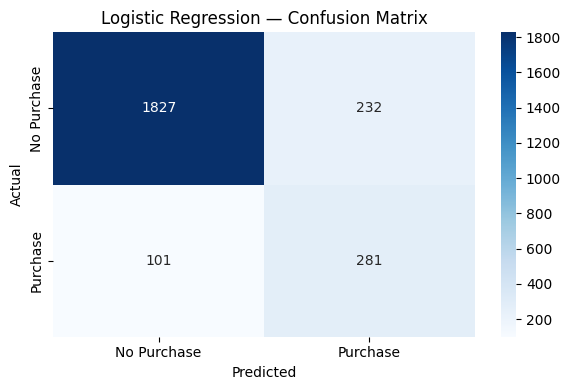

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Purchase', 'Purchase'],
            yticklabels=['No Purchase', 'Purchase'])
plt.title('Logistic Regression — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('lr_confusion_matrix.png', dpi=150)
plt.show()

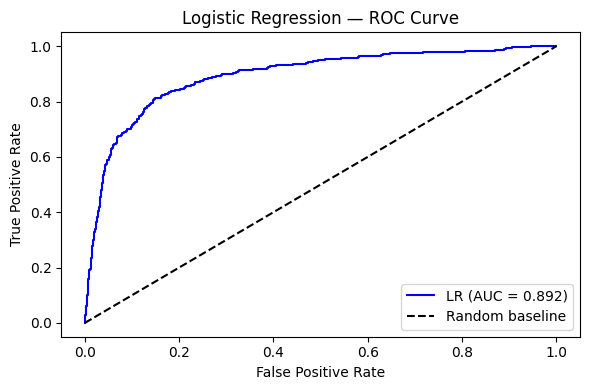

In [10]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='blue', label=f'LR (AUC = {auc:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression — ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig('lr_roc_curve.png', dpi=150)
plt.show()

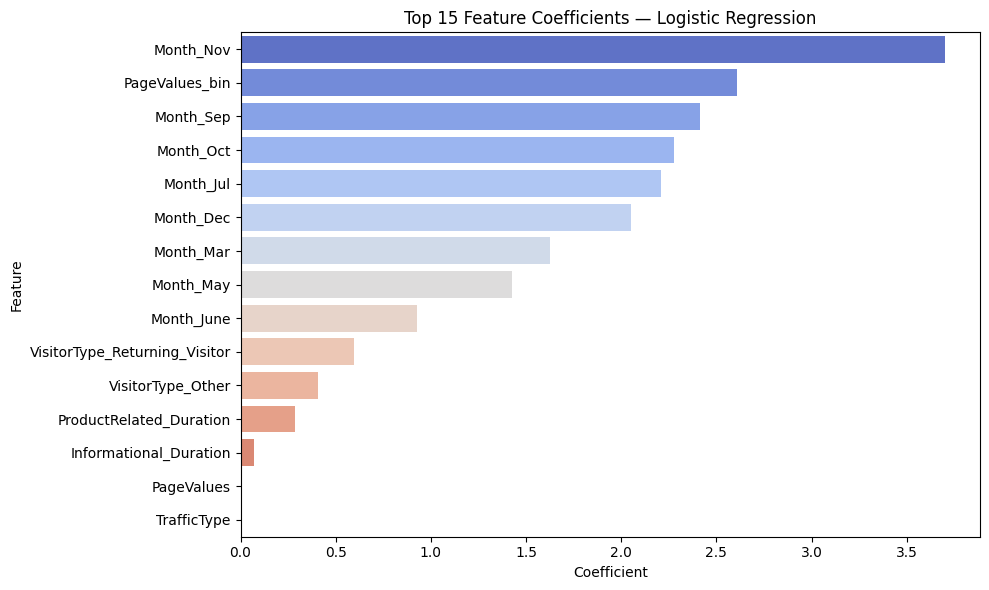

                          Feature  Coefficient
20                      Month_Nov     3.700146
25                 PageValues_bin     2.609783
22                      Month_Sep     2.412373
21                      Month_Oct     2.274864
16                      Month_Jul     2.210663
14                      Month_Dec     2.051459
18                      Month_Mar     1.627097
19                      Month_May     1.424059
17                     Month_June     0.924670
24  VisitorType_Returning_Visitor     0.598511


In [11]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature',
            data=coef_df.head(15), palette='coolwarm')
plt.title('Top 15 Feature Coefficients — Logistic Regression')
plt.tight_layout()
plt.savefig('lr_coefficients.png', dpi=150)
plt.show()

print(coef_df.head(10))

In [12]:
import shutil

# Save model
joblib.dump(lr_model, 'logistic_regression.pkl')
shutil.copy('logistic_regression.pkl', path + 'logistic_regression.pkl')

# Save plots
for plot in ['lr_confusion_matrix.png', 'lr_roc_curve.png', 'lr_coefficients.png']:
    shutil.copy(plot, path + plot)

print("Model and plots saved to Drive ✅")

Model and plots saved to Drive ✅


In [13]:
results = pd.DataFrame([{
    'Model': 'Logistic Regression',
    'Accuracy': round(accuracy, 4),
    'F1': round(f1, 4),
    'Precision': round(precision, 4),
    'Recall': round(recall, 4),
    'AUC': round(auc, 4)
}])

results.to_csv('lr_results.csv', index=False)
shutil.copy('lr_results.csv', path + 'lr_results.csv')
print("Results saved:")
print(results)

Results saved:
                 Model  Accuracy      F1  Precision  Recall     AUC
0  Logistic Regression    0.8636  0.6279     0.5478  0.7356  0.8918
